# 거치식·적립식 예금의 업종별 LP (수정본)

**리뷰 반영 사항**

| 리뷰 지적 | 수정 내용 |
|---|---|
| 대조군 없음 (처치군만으로 패널 구성) | 전체 법인으로 패널을 구성하고 팀 표준식의 교호작용 계수 β₃(노출 − 비노출 격차)를 추정 |
| rolling 365일 처치 정의 (2023년 창 불완전, 결과에 따라 처치가 바뀜) | 팀 표준: 36개월 중 1회 이상 외환실적 → `외환노출=1` (법인 단위, 시간 불변) |
| 사후 업종 선택 | 모든 결과에 **[탐색적 분석]** 표시, 업종 목록을 한 곳에서만 정의 |
| 표준오차 종류 미기재 | 본 추정 = 법인 군집 SE, 강건성 = 법인·연월 이중 군집 SE |
| 달력 통제 | 외환노출 × 월(1~12월) 더미를 본 추정에 포함 |
| 부호 뜻 확인 | 충격 변수의 단위와 β₃ 부호의 뜻을 4절에 명시 |

**추가 수정**
- 업종마다 처치군과 대조군 법인 수를 따로 표시
- 추정이 실패한 시차 h를 조용히 건너뛰지 않고 출력
- 강건성 검정 (본 추정은 팀 표준 그대로): 이중 군집 SE 2종, 지역×연월 FE, 잔액 양수 관측만, 사전 기간(2023년) 기준 처치, 달력 통제 제외, 사전 추세(placebo), leave-one-out, 보유 여부 LP
- 기존의 "대조군 vs 처치군 실제 반응 궤적" 그래프는 삭제 (이유는 마지막 절 참고)

**추정식 (팀 표준 + 달력 통제)**

$$\ln(y_{i,t+h}+1) - \ln(y_{i,t-1}+1) = \alpha_i + \delta_t + \beta_1\,\text{shock}_{r,t} + \beta_3\,(\text{shock}_{r,t} \times \text{외환노출}_i) + \sum_{m=2}^{12}\gamma_m\,(\text{외환노출}_i \times \mathbb{1}[\text{월}_t=m]) + \varepsilon_{i,t+h}$$

In [1]:
import math
import warnings
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

file_bank = r"C:\Users\dahye\OneDrive\바탕 화면\IM뱅크 교육\통계프로젝트\data.xlsx"
file_customs = r"C:\Users\dahye\OneDrive\바탕 화면\IM뱅크 교육\통계프로젝트\export_region.csv"

df_bank = pd.read_excel(file_bank)
df_customs = pd.read_csv(file_customs, encoding='utf-8')

### 1. 처치군 정의

- **당월_외환실적**: 해당 월에 수출·수입 실적 금액이 0보다 크거나 거래 건수가 있으면 1
- **외환노출 (본 추정, 팀 표준)**: 전체 36개월 중 한 번이라도 당월_외환실적이 1이면 1. 법인 단위로 시간에 따라 변하지 않으므로 수출 충격 때문에 수출을 멈춘 회사가 처치군에서 빠지는 문제가 없습니다.
- **외환노출_2023 (강건성)**: 2023년 12개월 안에만 실적이 있으면 1. 처치 정의에 결과 기간(2024년 이후)의 정보가 섞이지 않도록 한 버전이며, 이 버전의 회귀는 2024-01 이후 관측만 씁니다.

In [2]:
df_bank['외환_수출실적금액'] = pd.to_numeric(df_bank['외환_수출실적금액'], errors='coerce').fillna(0)
df_bank['외환_수입실적금액'] = pd.to_numeric(df_bank['외환_수입실적금액'], errors='coerce').fillna(0)

has_export_amt = df_bank['외환_수출실적금액'] > 0
has_import_amt = df_bank['외환_수입실적금액'] > 0
has_export_cnt = df_bank['외환_수출실적거래건수'].notna() & (df_bank['외환_수출실적거래건수'] != '0건')
has_import_cnt = df_bank['외환_수입실적거래건수'].notna() & (df_bank['외환_수입실적거래건수'] != '0건')

df_bank['당월_외환실적'] = (has_export_amt | has_import_amt | has_export_cnt | has_import_cnt).astype(int)
df_bank['기준년월'] = df_bank['기준년월'].astype(str)

firm_exposure = df_bank.groupby('법인ID')['당월_외환실적'].max().rename('외환노출')
firm_exposure_2023 = (df_bank[df_bank['기준년월'].str.startswith('2023')]
                      .groupby('법인ID')['당월_외환실적'].max().rename('외환노출_2023'))

print('기간:', df_bank['기준년월'].min(), '~', df_bank['기준년월'].max(), f"({df_bank['기준년월'].nunique()}개월)")
print('외환노출(36개월) 법인 수:', firm_exposure.value_counts().to_dict())
print('외환노출_2023 법인 수   :', firm_exposure_2023.value_counts().to_dict())

기간: 202301 ~ 202512 (36개월)
외환노출(36개월) 법인 수: {0: 13961, 1: 1512}
외환노출_2023 법인 수   : {0: 11093, 1: 1081}


### 2. 수출 충격 변수

관세청 지역별 수출액의 전년 동월 대비 증감률(`yoy_exp_amt`)을 사업장_시도×연월에 붙입니다.

In [3]:
df_customs['기준년월'] = df_customs['ym'].astype(str)
df_shock = df_customs[['region', '기준년월', 'yoy_exp_amt']].copy()
df_shock.rename(columns={'region': '사업장_시도', 'yoy_exp_amt': 'export_shock'}, inplace=True)
df_shock.dropna(subset=['export_shock'], inplace=True)

### 3. 패널 뼈대 (전체 법인 × 전체 연월)

- 원본과 같이 관측이 빠진 달은 0이 아닌 결측으로 둡니다.
- 원본과 달리 **처치군만이 아니라 전체 법인**으로 뼈대를 만듭니다. 대조군(외환노출=0)이 있어야 β₃를 식별할 수 있습니다.
- 거치식과 적립식은 각각 한 번이라도 잔액이 0보다 컸던 법인만 남깁니다.

In [4]:
all_firms = df_bank['법인ID'].unique()
all_months = sorted(df_bank['기준년월'].unique())
df_grid = pd.DataFrame(list(product(all_firms, all_months)), columns=['법인ID', '기준년월'])

firm_info = (df_bank.dropna(subset=['사업장_시도', '업종_중분류'])
             .groupby('법인ID')[['사업장_시도', '업종_중분류']].last().reset_index())
firm_info = (firm_info.merge(firm_exposure, on='법인ID', how='left')
                      .merge(firm_exposure_2023, on='법인ID', how='left'))

df_grid = df_grid.merge(firm_info, on='법인ID', how='left')
df_grid = df_grid.merge(df_shock, on=['사업장_시도', '기준년월'], how='left')

bank_subset = df_bank[['법인ID', '기준년월', '거치식예금잔액', '적립식예금잔액']]
df_merged = df_grid.merge(bank_subset, on=['법인ID', '기준년월'], how='left')

df_merged['log_거치식'] = np.log1p(df_merged['거치식예금잔액'])
df_merged['log_적립식'] = np.log1p(df_merged['적립식예금잔액'])

# 보유 여부 (잔액 > 0 이면 1, 관측 없는 달은 결측 유지) - 7-3절에서 사용
for acct in ['거치식', '적립식']:
    bal = df_merged[f'{acct}예금잔액']
    df_merged[f'has_{acct}'] = (bal > 0).astype(float).where(bal.notna())


def make_panel(df, balance_col):
    valid = df.groupby('법인ID')[balance_col].max()
    out = df[df['법인ID'].isin(valid[valid > 0].index)].copy()
    out['기준년월'] = pd.to_datetime(out['기준년월'], format='%Y%m')
    return out.sort_values(['법인ID', '기준년월']).set_index(['법인ID', '기준년월'])


df_time = make_panel(df_merged, '거치식예금잔액')
df_install = make_panel(df_merged, '적립식예금잔액')
print('거치식 패널:', df_time.index.get_level_values(0).nunique(), '법인')
print('적립식 패널:', df_install.index.get_level_values(0).nunique(), '법인')

거치식 패널: 1138 법인
적립식 패널: 957 법인


### 4. LP 추정 함수

- 종속변수: $\ln(y_{t+h}+1) - \ln(y_{t-1}+1)$, h = 0~12. 상하위 1%로 윈저라이징합니다.
- 법인 FE와 연월 FE를 넣습니다. `외환노출`은 시간에 따라 변하지 않아 법인 FE에 흡수되므로 단독 항으로 넣지 않습니다.
- **해석할 계수는 β₃뿐입니다.** 연월 FE가 있으면 β₁은 대조군의 절대 반응이 아니라 대조군 안에서 본 대구와 경북의 차이입니다.
- **달력 통제**: 연월 FE는 모든 법인에 공통인 달력 효과만 흡수합니다. 노출 법인에만 나타나는 계절성(분기말·연말 자금 이동 등)이 수출 증감률의 계절 패턴과 겹쳐 β₃에 섞이지 않도록 `외환노출 × 월 더미`(1월 기준, 11개)를 넣습니다. 월 더미 단독 항은 연월 FE에 흡수되므로 넣지 않습니다.
- **단위와 부호**
  - `export_shock` = 지역 수출액의 전년 동월 대비 증감률(%). 값이 클수록 수출이 좋다는 뜻입니다. 2023~2025년 범위는 대구 −30%~+48%, 경북 −31%~+12%입니다.
  - 종속변수는 로그 차분이므로 β₃ = "수출 증감률 1%p 상승 시 노출 법인과 비노출 법인의 누적 로그 예금 변화 격차"입니다. 10%p 충격이면 β₃ × 10입니다.
  - **β₃ < 0**: 수출이 좋아지면 노출 법인의 예금이 비노출 법인보다 상대적으로 **줄고**, 수출이 나빠지면 상대적으로 **늘어납니다.** "수출 하락 → 예금 소진" 가설과 부합하려면 β₃ > 0이어야 합니다.
  - 팀 표준 식에는 하락 국면 더미가 없으므로 β₃는 상승과 하락에 같은 크기로 작용하는 **대칭 효과**입니다. 원본의 하락 국면 비대칭 계수와 바로 비교할 수 없습니다.
- 표준오차: `cluster='entity'`(법인 군집, 본 추정), `cluster='twoway'`(법인·연월 이중 군집, 강건성). 충격이 지역×월 단위로 같은 값이라 법인 군집만 쓰면 SE가 작게 잡힐 수 있습니다. 지역이 2개뿐이라 지역 군집은 할 수 없습니다.
- 추정이 실패한 h는 건너뛰지 않고 이유를 출력합니다.

In [5]:
def run_lp(data, dep_var, shock_var='export_shock', exposure_var='외환노출',
           hs=range(0, 13), cluster='entity', fe='time', start=None, calendar=True,
           positive_only=False, winsorize=True, label='', verbose=True):
    # fe: 'time' = 연월 FE (팀 표준) | 'region_time' = 지역×연월 FE
    # cluster: 'entity' = 법인 | 'twoway' = 법인·연월 | 'entity_regiontime' = 법인·지역×연월
    # positive_only: t-1과 t+h 잔액이 모두 양수인 관측만 사용 (계좌 개설·해지 제외)
    # winsorize: 종속변수 상하위 1% 자르기. -1/0/+1 값인 보유 여부 LP에서는 False
    # hs에 음수 h를 넣으면 사전 추세(placebo) 검정: y_{t+h} - y_{t-1}, h <= -2
    data = data.copy()
    results, failed = [], []
    dates = data.index.get_level_values(1)
    cal_cols = [f'cal_m{m}' for m in range(2, 13)] if calendar else []
    for m in range(2, 13):
        data[f'cal_m{m}'] = (dates.month == m).astype(int) * data[exposure_var]
    data['region_time'] = pd.factorize(data['사업장_시도'].astype(str) + '_' + dates.strftime('%Y%m'))[0]
    y_lag = data.groupby(level=0)[dep_var].shift(1)
    for h in hs:
        if h == -1:
            continue
        y_forward = data.groupby(level=0)[dep_var].shift(-h)
        dep = f'delta_h{h}'
        data[dep] = y_forward - y_lag
        if positive_only:
            data.loc[~((y_lag > 0) & (y_forward > 0)), dep] = np.nan

        reg_data = data[[dep, shock_var, exposure_var, 'region_time'] + cal_cols].dropna()
        if start is not None:
            reg_data = reg_data[reg_data.index.get_level_values(1) >= pd.Timestamp(start)]
        if reg_data.empty or reg_data[exposure_var].nunique() < 2:
            failed.append((h, '처치군 또는 대조군 없음'))
            continue

        if winsorize:
            lo, hi = reg_data[dep].quantile([0.01, 0.99])
            reg_data[dep] = reg_data[dep].clip(lo, hi)
        reg_data['const'] = 1
        reg_data['interaction'] = reg_data[shock_var] * reg_data[exposure_var]

        if fe == 'region_time':
            # 지역×연월 FE가 충격 단독 항(β₁)을 흡수하므로 β₃만 남음
            mod = PanelOLS(reg_data[dep], reg_data[['const', 'interaction'] + cal_cols],
                           entity_effects=True, other_effects=reg_data[['region_time']],
                           drop_absorbed=True)
        else:
            mod = PanelOLS(reg_data[dep], reg_data[['const', shock_var, 'interaction'] + cal_cols],
                           entity_effects=True, time_effects=True, drop_absorbed=True)
        try:
            if cluster == 'entity_regiontime':
                clusters = pd.DataFrame({'firm': pd.factorize(reg_data.index.get_level_values(0))[0],
                                         'region_time': reg_data['region_time'].astype(int)},
                                        index=reg_data.index)
                res = mod.fit(cov_type='clustered', clusters=clusters)
            else:
                res = mod.fit(cov_type='clustered', cluster_entity=True,
                              cluster_time=(cluster == 'twoway'))
        except Exception as e:
            failed.append((h, f'{type(e).__name__}: {e}'))
            continue

        firms = reg_data.groupby(level=0)[exposure_var].first()
        results.append({
            'h': h,
            'coef_beta3': res.params['interaction'],
            'se': res.std_errors['interaction'],
            'p_value': res.pvalues['interaction'],
            'n_obs': int(res.nobs),
            'n_treat': int((firms == 1).sum()),
            'n_ctrl': int((firms == 0).sum()),
        })
    if verbose:
        for h, msg in failed:
            print(f'  [추정 실패] {label} h={h}: {msg}')
    return pd.DataFrame(results)


def stars(p):
    return '**' if p < 0.05 else ('*' if p < 0.1 else '')


def summarize(results_dict, hs=(3, 6, 12)):
    rows = []
    for ind, r in results_dict.items():
        df_res = r['df']
        row = {'업종명': ind, '처치군': r['n_treat'], '대조군': r['n_ctrl']}
        for h in hs:
            hd = df_res[df_res['h'] == h]
            if hd.empty:
                row[f'h={h} β₃'] = '추정 실패'
                row[f'h={h} p'] = ''
            else:
                p = hd['p_value'].iloc[0]
                row[f'h={h} β₃'] = f"{hd['coef_beta3'].iloc[0]:.4f} {stars(p)}"
                row[f'h={h} p'] = f'{p:.3f}'
        rows.append(row)
    return pd.DataFrame(rows)

### 5. 분석 대상 업종 **[탐색적 분석]**

아래 세 업종은 원본 작업에서 상위 10개 업종 × 2계정 × 13시차를 본 뒤 **사후에 고른** 것입니다. 따라서 이 절 이후의 모든 결과는 탐색적 분석으로 읽어야 하며, 유의성도 다중 비교를 감안해 보수적으로 해석해야 합니다.

업종 목록은 이 셀에서만 정의하고, 이후 모든 표와 그래프가 같은 목록을 씁니다. 업종에 포함된 법인 수가 20곳 이상일 때만 추정하며, 처치군과 대조군 수를 따로 표시합니다.

In [6]:
TARGET_INDUSTRIES = [
    '기타 기계 및 장비 제조업',
    '도매 및 상품 중개업',
    '1차 금속 제조업',
]
MIN_FIRMS = 20

rows = []
for acct, panel in [('거치식', df_time), ('적립식', df_install)]:
    firms = panel.groupby(level=0)[['업종_중분류', '외환노출']].first()
    for ind in TARGET_INDUSTRIES:
        f = firms[firms['업종_중분류'] == ind]
        rows.append({'계정': acct, '업종명': ind, '전체': len(f),
                     '처치군(외환노출=1)': int((f['외환노출'] == 1).sum()),
                     '대조군(외환노출=0)': int((f['외환노출'] == 0).sum())})
print(pd.DataFrame(rows).to_string(index=False))

 계정            업종명  전체  처치군(외환노출=1)  대조군(외환노출=0)
거치식 기타 기계 및 장비 제조업  58           24           34
거치식    도매 및 상품 중개업 155           29          126
거치식      1차 금속 제조업  39           24           15
적립식 기타 기계 및 장비 제조업  55           18           37
적립식    도매 및 상품 중개업 194           50          144
적립식      1차 금속 제조업  40           15           25


### 6. 본 추정: β₃ (달력 통제 포함, 법인 군집 SE) **[탐색적 분석]**

아래 셀에서 출력되는 **확정판 표**가 이 파트의 산출물입니다(3개 업종 × 거치식·적립식).

In [7]:
def run_by_industry(panel, dep_var, **kw):
    out = {}
    for ind in TARGET_INDUSTRIES:
        df_ind = panel[panel['업종_중분류'] == ind]
        if df_ind.index.get_level_values(0).nunique() < MIN_FIRMS:
            print(f'  [제외] {ind}: 법인 수 {MIN_FIRMS}곳 미만')
            continue
        res = run_lp(df_ind, dep_var, label=f'{ind} {dep_var}', **kw)
        if not res.empty:
            out[ind] = {'df': res, 'n_treat': res['n_treat'].max(), 'n_ctrl': res['n_ctrl'].max()}
    return out


results_time = run_by_industry(df_time, 'log_거치식')
results_install = run_by_industry(df_install, 'log_적립식')

final_rows = []
for acct, r in [('거치식', results_time), ('적립식', results_install)]:
    s = summarize(r)
    s.insert(0, '계정', acct)
    final_rows.append(s)
final_table = pd.concat(final_rows, ignore_index=True)
final_table.insert(0, '구분', '[탐색적 분석]')

print('[확정판] 업종 3개 × 거치식·적립식 β₃  [탐색적 분석]')
print('β₃ = 수출 증감률(전년 동월 대비) 1%p 상승 시 노출 − 비노출 법인의 누적 로그 예금 변화 격차')
print('β₃ < 0: 수출 호조 때 노출 법인 예금이 상대적으로 감소 (= 수출 부진 때 상대적으로 증가)')
print('통제: 법인 FE, 연월 FE, 외환노출 × 월 더미 | SE: 법인 군집 | ** p<0.05, * p<0.1')
print('=' * 120)
print(final_table.to_string(index=False))

[확정판] 업종 3개 × 거치식·적립식 β₃  [탐색적 분석]
β₃ = 수출 증감률(전년 동월 대비) 1%p 상승 시 노출 − 비노출 법인의 누적 로그 예금 변화 격차
β₃ < 0: 수출 호조 때 노출 법인 예금이 상대적으로 감소 (= 수출 부진 때 상대적으로 증가)
통제: 법인 FE, 연월 FE, 외환노출 × 월 더미 | SE: 법인 군집 | ** p<0.05, * p<0.1
      구분  계정            업종명  처치군  대조군     h=3 β₃ h=3 p     h=6 β₃ h=6 p    h=12 β₃ h=12 p
[탐색적 분석] 거치식 기타 기계 및 장비 제조업   19   21    0.0107  0.525   -0.0206  0.358 -0.0821 **  0.036
[탐색적 분석] 거치식    도매 및 상품 중개업   20   85    0.0012  0.843    0.0040  0.679   -0.0001   0.996
[탐색적 분석] 거치식      1차 금속 제조업   19   11 -0.0209 ** 0.019 -0.0477 ** 0.000 -0.0941 **  0.000
[탐색적 분석] 적립식 기타 기계 및 장비 제조업   12   22   -0.0040  0.675   -0.0044  0.725   -0.0164   0.449
[탐색적 분석] 적립식    도매 및 상품 중개업   25  103   -0.0035  0.410   -0.0101  0.189   -0.0084   0.437
[탐색적 분석] 적립식      1차 금속 제조업   11   14   -0.0135  0.121  -0.0224 * 0.065   -0.0320   0.171


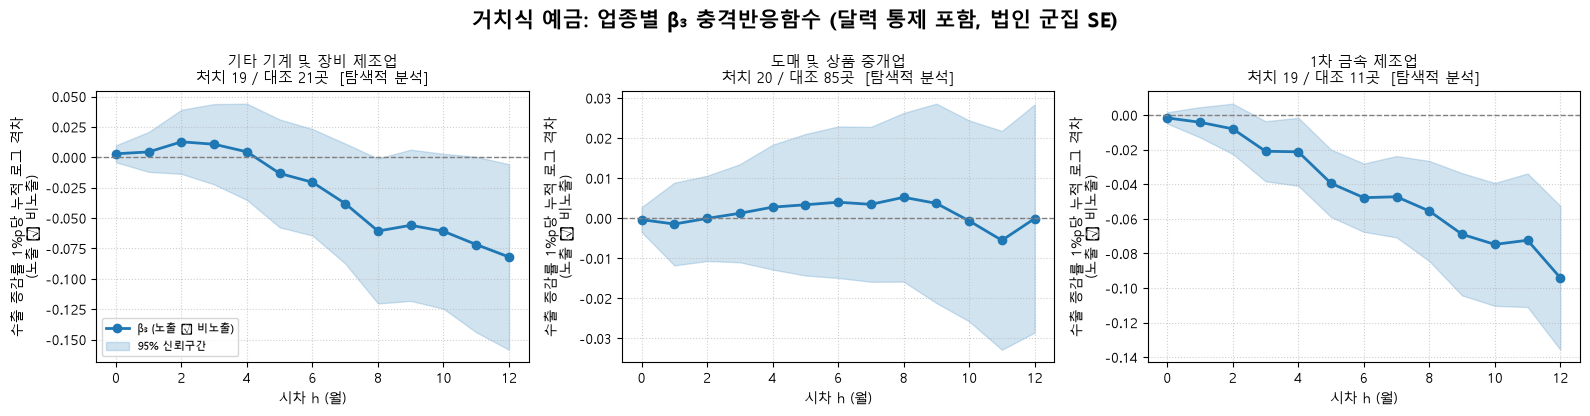

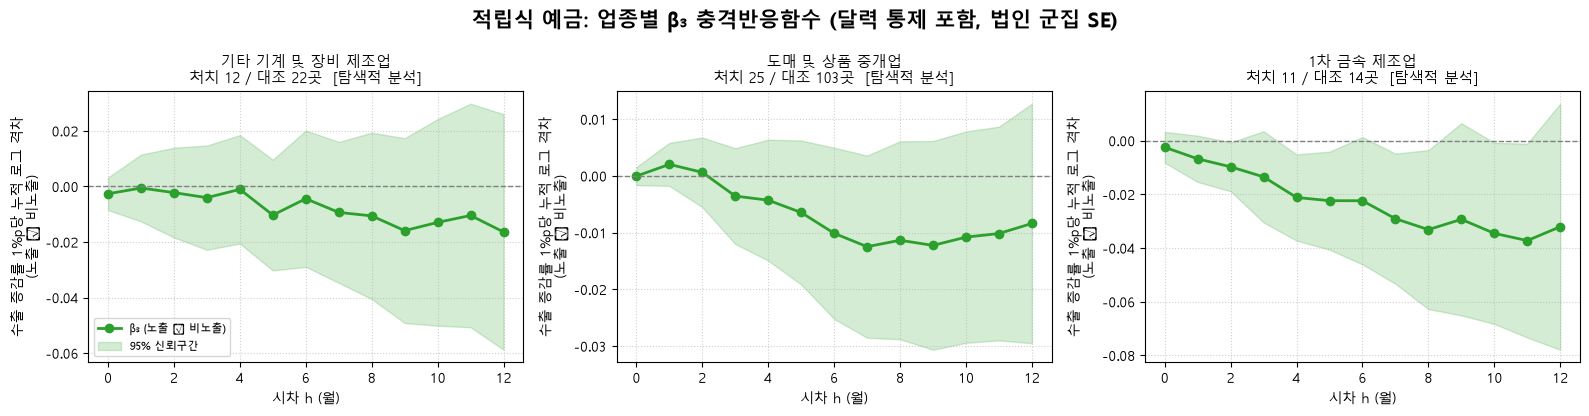

In [8]:
def plot_irf(results_dict, title, color):
    inds = [i for i in TARGET_INDUSTRIES if i in results_dict]
    if not inds:
        print(f'{title}: 그릴 결과 없음')
        return
    n_cols = 3
    n_rows = math.ceil(len(inds) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.2 * n_rows), squeeze=False)
    for ax, ind in zip(axes.flat, inds):
        r = results_dict[ind]
        d = r['df']
        ax.plot(d['h'], d['coef_beta3'], marker='o', color=color, linewidth=2, label='β₃ (노출 − 비노출)')
        ax.fill_between(d['h'], d['coef_beta3'] - 1.96 * d['se'], d['coef_beta3'] + 1.96 * d['se'],
                        color=color, alpha=0.2, label='95% 신뢰구간')
        ax.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_title(f"{ind}\n처치 {r['n_treat']} / 대조 {r['n_ctrl']}곳  [탐색적 분석]", fontsize=11)
        ax.set_xlabel('시차 h (월)')
        ax.set_ylabel('수출 증감률 1%p당 누적 로그 격차\n(노출 − 비노출)')
        ax.set_xticks(range(0, 13, 2))
        ax.grid(True, linestyle=':', alpha=0.6)
    axes.flat[0].legend(loc='lower left', fontsize=8)
    for ax in list(axes.flat)[len(inds):]:
        ax.axis('off')
    fig.suptitle(f'{title}: 업종별 β₃ 충격반응함수 (달력 통제 포함, 법인 군집 SE)', fontsize=15, fontweight='bold')
    fig.tight_layout()
    plt.show()


plot_irf(results_time, '거치식 예금', 'tab:blue')
plot_irf(results_install, '적립식 예금', 'tab:green')

### 7. 강건성 검정

팀 전체가 같은 사양(6절 본 추정)을 쓰므로 본 추정은 바꾸지 않고, 아래 검정은 모두 **본 추정에서 한 가지만 바꾼** 비교용입니다.

| 사양 | 바꾼 것 | 확인하려는 것 |
|---|---|---|
| 이중 군집 SE (법인·연월) | SE | 같은 달 모든 법인에 공통인 충격 |
| 이중 군집 SE (법인·지역×연월) | SE | 충격 값이 2개 지역 × 36개월뿐이라 법인 군집 SE가 과소 추정될 가능성. 군집이 72개 이하라 이것도 근사치 |
| 지역×연월 FE | 고정효과 | 지역 경기처럼 지역 전체에 오는 변화가 β₃에 섞이는지. 같은 지역·같은 달 안에서 노출 대 비노출만 비교 (β₁은 흡수됨) |
| 잔액 양수 관측만 | 표본 | log(잔액+1)에서 0 ↔ 양수 전환(계좌 개설·해지)이 계수를 키우는지 |
| 2023 기준 처치 (2024~ 추정) | 처치 정의 | 결과 기간 정보로 처치가 정해지는 문제. 2023년에 관측되지 않은 법인은 빠지므로 표본도 다름 |
| 달력 통제 제외 | 통제 | 외환노출 × 월 더미의 영향 (2번정리와 같은 사양) |

In [9]:
robust = {
    '이중 군집 SE (법인·연월)': dict(cluster='twoway'),
    '이중 군집 SE (법인·지역×연월)': dict(cluster='entity_regiontime'),
    '지역×연월 FE': dict(fe='region_time'),
    '잔액 양수 관측만': dict(positive_only=True),
    '2023 기준 처치 (2024~ 추정)': dict(exposure_var='외환노출_2023', start='2024-01-01'),
    '달력 통제 제외': dict(calendar=False),
}

rob_rows = []
for acct, panel, dep, base in [('거치식', df_time, 'log_거치식', results_time),
                               ('적립식', df_install, 'log_적립식', results_install)]:
    specs = {'본 추정': base}
    for name, kw in robust.items():
        specs[name] = run_by_industry(panel, dep, **kw)
    for spec, res in specs.items():
        s = summarize(res)
        s.insert(0, '사양', spec)
        s.insert(0, '계정', acct)
        rob_rows.append(s)

rob_table = pd.concat(rob_rows, ignore_index=True).sort_values(['계정', '업종명'], kind='stable')
print('[탐색적 분석] 강건성 비교  ** p<0.05, * p<0.1')
print(rob_table.to_string(index=False))

[탐색적 분석] 강건성 비교  ** p<0.05, * p<0.1
 계정                    사양            업종명  처치군  대조군     h=3 β₃ h=3 p     h=6 β₃ h=6 p    h=12 β₃ h=12 p
거치식                  본 추정      1차 금속 제조업   19   11 -0.0209 ** 0.019 -0.0477 ** 0.000 -0.0941 **  0.000
거치식      이중 군집 SE (법인·연월)      1차 금속 제조업   19   11 -0.0209 ** 0.029 -0.0477 ** 0.000 -0.0941 **  0.000
거치식   이중 군집 SE (법인·지역×연월)      1차 금속 제조업   19   11 -0.0209 ** 0.034 -0.0477 ** 0.000 -0.0941 **  0.000
거치식              지역×연월 FE      1차 금속 제조업   19   11 -0.0228 ** 0.015 -0.0496 ** 0.000 -0.0997 **  0.000
거치식             잔액 양수 관측만      1차 금속 제조업   18   10    0.0027  0.336    0.0021  0.488    0.0023   0.696
거치식 2023 기준 처치 (2024~ 추정)      1차 금속 제조업   14   15   -0.0078  0.677   -0.0361  0.273  -0.0674 *  0.069
거치식              달력 통제 제외      1차 금속 제조업   19   11  -0.0170 * 0.086 -0.0331 ** 0.020 -0.0820 **  0.000
거치식                  본 추정 기타 기계 및 장비 제조업   19   21    0.0107  0.525   -0.0206  0.358 -0.0821 **  0.036
거치식      이중 군집 SE (법인·연월) 기타 기계 및 장비 

### 7-1. 사전 추세(placebo) 검정

충격 시점 t **이전**의 예금 변화($y_{t+h} - y_{t-1}$, h = −6 ~ −2)를 t시점 충격에 회귀합니다. 노출 법인과 비노출 법인이 충격 전부터 다르게 움직이지 않았다면 β₃는 0 근처여야 합니다. 나머지 사양은 본 추정과 같습니다.

**한계**: 수출 증감률은 지속성이 강합니다(대구 1개월 자기상관 0.64). 그래서 t시점 충격은 과거 충격과 겹치고, placebo 계수가 0이 아니어도 "사전 추세" 때문인지 "과거 충격의 효과" 때문인지 가릴 수 없습니다. 반대로 0 근처라면 사전 추세가 없다는 근거로 쓸 수 있습니다.

In [10]:
PLACEBO_HS = [-6, -5, -4, -3, -2]
pl_rows = []
for acct, panel, dep in [('거치식', df_time, 'log_거치식'), ('적립식', df_install, 'log_적립식')]:
    res = run_by_industry(panel, dep, hs=PLACEBO_HS)
    s = summarize(res, hs=PLACEBO_HS)
    s.insert(0, '계정', acct)
    pl_rows.append(s)

print('[탐색적 분석] 사전 추세(placebo) 검정: β₃가 0 근처면 사전 추세 없음  ** p<0.05, * p<0.1')
print(pd.concat(pl_rows, ignore_index=True).to_string(index=False))

[탐색적 분석] 사전 추세(placebo) 검정: β₃가 0 근처면 사전 추세 없음  ** p<0.05, * p<0.1
 계정            업종명  처치군  대조군  h=-6 β₃ h=-6 p  h=-5 β₃ h=-5 p  h=-4 β₃ h=-4 p  h=-3 β₃ h=-3 p  h=-2 β₃ h=-2 p
거치식 기타 기계 및 장비 제조업   19   21 -0.0158   0.502 -0.0160   0.438 -0.0140   0.428 -0.0089   0.402 -0.0002   0.966
거치식    도매 및 상품 중개업   20   85 -0.0073   0.412 -0.0089   0.181 -0.0097   0.146 -0.0036   0.545 -0.0010   0.531
거치식      1차 금속 제조업   19   11 -0.0038   0.778  0.0026   0.800  0.0053   0.599  0.0057   0.429  0.0006   0.480
적립식 기타 기계 및 장비 제조업   12   22 -0.0167   0.306 -0.0091   0.498  0.0024   0.818  0.0048   0.451  0.0007   0.824
적립식    도매 및 상품 중개업   25  102 -0.0037   0.522 -0.0028   0.522 -0.0044   0.134 -0.0010   0.597 -0.0006   0.509
적립식      1차 금속 제조업   11   14 -0.0150   0.208 -0.0078   0.395 -0.0041   0.583 -0.0049   0.386 -0.0003   0.913


### 7-2. 법인 하나씩 빼고 재추정 (leave-one-out)

거치식에서 유의했던 두 결과(1차 금속, 기타 기계)가 특정 법인 한두 곳에 좌우되는지 확인합니다. 추정에 쓰인 법인을 한 곳씩 빼고 본 추정을 다시 돌려 h=6, h=12의 β₃ 분포를 봅니다.

In [11]:
LOO_TARGETS = ['1차 금속 제조업', '기타 기계 및 장비 제조업']
LOO_HS = [6, 12]

loo_summary = []
for ind in LOO_TARGETS:
    df_ind = df_time[df_time['업종_중분류'] == ind]
    firms = df_ind.dropna(subset=['export_shock']).index.get_level_values(0).unique()
    base = results_time[ind]['df'].set_index('h')
    rows = []
    for f in firms:
        r = run_lp(df_ind.drop(index=f, level=0), 'log_거치식', hs=LOO_HS, verbose=False)
        for _, row in r.iterrows():
            rows.append({'제외 법인': f, 'h': int(row['h']),
                         'coef': row['coef_beta3'], 'p': row['p_value']})
    loo = pd.DataFrame(rows)
    for h in LOO_HS:
        d = loo[loo['h'] == h]
        worst = d.loc[(d['coef'] - base.loc[h, 'coef_beta3']).abs().idxmax()]
        loo_summary.append({
            '업종명': ind, 'h': h,
            '본 추정 β₃': round(base.loc[h, 'coef_beta3'], 4),
            'LOO 최소': round(d['coef'].min(), 4),
            'LOO 최대': round(d['coef'].max(), 4),
            '부호 바뀜': int((np.sign(d['coef']) != np.sign(base.loc[h, 'coef_beta3'])).sum()),
            'p≥0.05 된 횟수': int((d['p'] >= 0.05).sum()),
            '재추정 수': len(d),
            '영향 최대 법인': worst['제외 법인'],
        })

print('[탐색적 분석] 거치식 leave-one-out')
# 영향 최대 법인(법인ID)은 공개 저장소에 남기지 않도록 출력에서 뺀다
print(pd.DataFrame(loo_summary).drop(columns=['영향 최대 법인']).to_string(index=False))

[탐색적 분석] 거치식 leave-one-out
           업종명  h  본 추정 β₃  LOO 최소  LOO 최대  부호 바뀜  p≥0.05 된 횟수  재추정 수
     1차 금속 제조업  6  -0.0477 -0.0511 -0.0423      0            0     30
     1차 금속 제조업 12  -0.0941 -0.0999 -0.0832      0            1     30
기타 기계 및 장비 제조업  6  -0.0206 -0.0329 -0.0098      0           42     42
기타 기계 및 장비 제조업 12  -0.0821 -0.0950 -0.0536      0            6     42


### 7-3. 보유 여부 LP (계좌 개설·해지 직접 검정)

7절에서 "잔액 양수 관측만" 쓰면 거치식 효과가 사라졌습니다. 이것만으로는 효과가 계좌 개설·해지에서 나온다고 **추론**할 수 있을 뿐이므로, 여기서 직접 확인합니다.

- 종속변수: $\mathbb{1}[\text{잔액}_{i,t+h}>0] - \mathbb{1}[\text{잔액}_{i,t-1}>0]$ (보유 상태 변화, −1 / 0 / +1)
- 나머지(법인 FE, 연월 FE, 외환노출 × 월 더미, 법인 군집 SE)는 본 추정과 같은 선형확률모형입니다.
- **상하위 1% 자르기(윈저라이징)는 끕니다.** 값이 −1/0/+1뿐이라, 개설·해지가 전체의 1% 미만이면 1%·99% 분위수가 모두 0이 되어 개설·해지가 전부 0으로 바뀌기 때문입니다. 비교를 위해 자르기를 켠 결과도 함께 출력합니다.
- **β₃ 해석**: 수출 증감률 1%p 상승 시 노출 법인과 비노출 법인의 보유 확률 변화 격차입니다. × 100을 하면 %p이고, 10%p 충격이면 × 10입니다.
- β₃ < 0: 수출이 부진할 때 노출 법인이 계좌를 상대적으로 더 **유지하거나 새로 개설**합니다.

판단 기준: 1차 금속 거치식에서 β₃가 유의하게 음(−)이면 "보유 여부 차이" 해석이 확인되고, 아니면 9절의 해석을 고쳐야 합니다.

In [12]:
# 개설·해지(−1/+1)가 관측의 몇 %인지 확인 (1% 미만이면 자르기가 전부 0으로 만듦)
share_rows = []
for acct, panel in [('거치식', df_time), ('적립식', df_install)]:
    y = f'has_{acct}'
    y_lag = panel.groupby(level=0)[y].shift(1)
    for h in [0, 3, 6, 12]:
        d = (panel.groupby(level=0)[y].shift(-h) - y_lag)
        d = d[panel['export_shock'].notna()].dropna()
        share_rows.append({'계정': acct, 'h': h, '해지(−1) %': round((d == -1).mean() * 100, 2),
                           '개설(+1) %': round((d == 1).mean() * 100, 2)})
print('[참고] 보유 상태가 바뀐 관측 비율 (3개 업종 전체가 아닌 계정 패널 전체 기준)')
print(pd.DataFrame(share_rows).to_string(index=False))

ext_rows = []
for acct, panel in [('거치식', df_time), ('적립식', df_install)]:
    for spec, w in [('자르기 끔 (본 사양)', False), ('자르기 켬 (비교)', True)]:
        res = run_by_industry(panel, f'has_{acct}', winsorize=w)
        s = summarize(res, hs=(0, 3, 6, 12))
        s.insert(0, '사양', spec)
        s.insert(0, '계정', acct)
        ext_rows.append(s)

print()
print('[탐색적 분석] 보유 여부 LP: β₃ = 수출 증감률 1%p당 노출 − 비노출 보유 확률 변화 격차')
print('β₃ < 0: 수출 부진 때 노출 법인이 계좌를 상대적으로 더 유지·개설  ** p<0.05, * p<0.1')
print(pd.concat(ext_rows, ignore_index=True).sort_values(['계정', '업종명'], kind='stable').to_string(index=False))

[참고] 보유 상태가 바뀐 관측 비율 (3개 업종 전체가 아닌 계정 패널 전체 기준)
 계정  h  해지(−1) %  개설(+1) %
거치식  0      1.84      1.75
거치식  3      5.90      5.88
거치식  6      8.66      8.80
거치식 12     12.34     12.66
적립식  0      1.67      1.52
적립식  3      5.89      5.19
적립식  6      9.56      8.41
적립식 12     15.67     13.58


  [추정 실패] 1차 금속 제조업 has_거치식 h=0: ZeroDivisionError: division by zero



[탐색적 분석] 보유 여부 LP: β₃ = 수출 증감률 1%p당 노출 − 비노출 보유 확률 변화 격차
β₃ < 0: 수출 부진 때 노출 법인이 계좌를 상대적으로 더 유지·개설  ** p<0.05, * p<0.1
 계정           사양            업종명  처치군  대조군     h=0 β₃ h=0 p     h=3 β₃ h=3 p     h=6 β₃ h=6 p    h=12 β₃ h=12 p
거치식 자르기 끔 (본 사양)      1차 금속 제조업   19   11   -0.0008  0.400 -0.0043 ** 0.025 -0.0090 ** 0.000 -0.0169 **  0.000
거치식   자르기 켬 (비교)      1차 금속 제조업   19   11      추정 실패       -0.0043 ** 0.025 -0.0090 ** 0.000 -0.0169 **  0.000
거치식 자르기 끔 (본 사양) 기타 기계 및 장비 제조업   19   21    0.0007  0.394    0.0018  0.583   -0.0025  0.567  -0.0103 *  0.083
거치식   자르기 켬 (비교) 기타 기계 및 장비 제조업   19   21    0.0007  0.394    0.0018  0.583   -0.0025  0.567  -0.0103 *  0.083
거치식 자르기 끔 (본 사양)    도매 및 상품 중개업   20   85   -0.0003  0.617    0.0003  0.832    0.0012  0.532    0.0005   0.850
거치식   자르기 켬 (비교)    도매 및 상품 중개업   20   85   -0.0003  0.617    0.0003  0.832    0.0012  0.532    0.0005   0.850
적립식 자르기 끔 (본 사양)      1차 금속 제조업   11   14   -0.0014  0.183   -0.0044  0.195   -0.0059  0.140   -0.0094  


### 9. 결과 해석

**표본 주의**: 수출 충격 변수는 대구와 경북에만 있어서 다른 지역 법인은 회귀에서 빠집니다. 업종마다 처치군과 대조군이 각각 10~25곳이고, 충격 변수도 2개 지역 × 36개월의 변동뿐이라 신뢰구간은 넓게 읽어야 합니다.

**부호 읽는 법 (4절 참고)**: β₃ < 0이면 수출이 **부진할 때** 노출 법인의 예금이 비노출 법인보다 상대적으로 **늘어난다**는 뜻입니다. "수출 하락 → 예금 소진" 가설과는 반대 방향입니다.

#### 본 추정 (6절 확정판 표)

| 업종 | 거치식 | 적립식 |
|---|---|---|
| 1차 금속 | h=3 −0.021, h=6 −0.048, h=12 −0.094 (모두 p<0.05) | 음(−)이지만 h=6만 p=0.065 |
| 기타 기계 | h=12에서만 −0.082 (p=0.036) | 유의하지 않음 |
| 도매·상품중개 | 0 근처 | 0 근처 |

#### 강건성 검정 (7절)

| 검정 | 1차 금속 거치식 | 기타 기계 거치식 h=12 |
|---|---|---|
| 이중 군집 SE 2종 | 유지 | 유지 |
| 지역×연월 FE | 유지 (조금 커짐) | 유지 |
| 달력 통제 제외 | 유지 (조금 작아짐) | 유지 |
| 사전 추세(placebo) | h=−6~−2 모두 유의하지 않음 → 사전 추세 근거 없음 | 모두 유의하지 않음 |
| Leave-one-out | 30회 모두 부호 유지, h=12에서 1회만 p≥0.05 → 특정 법인에 좌우되지 않음 | 부호는 유지, 42회 중 6회 p≥0.05 |
| 2023 기준 처치 | h=12 −0.067 (p=0.069)로 약해짐 | 유의하지 않음 |
| 잔액 양수 관측만 | **모든 h에서 0 근처** | **0 근처** |
| **보유 여부 LP (7-3, 자르기 끔)** | **h=3 −0.0043, h=6 −0.0090, h=12 −0.0169 (모두 p<0.05)** | −0.0103 (p=0.083) |

#### 거치식 결과는 잔액 규모가 아니라 보유 여부의 차이입니다

두 검정이 같은 방향을 가리킵니다.
- **잔액 양수 관측만**: 거치식 계좌가 이미 있는 법인만 보면 β₃가 0 근처입니다. 잔액 **규모**는 수출 충격에 따라 다르게 움직이지 않습니다.
- **보유 여부 LP**: 1차 금속 거치식의 보유 확률 β₃가 h=3 이후 모든 시차에서 유의하게 음(−)입니다. 수출 증감률이 10%p 낮으면 12개월 뒤 노출 법인의 거치식 보유 확률이 비노출 법인보다 약 17%p 높습니다(−0.0169 × 10). 수출 부진기에 노출 법인이 거치식 예금을 상대적으로 더 **새로 들거나 덜 해지**한다는 뜻입니다.

본 추정의 크기(10%p당 로그 약 −0.94)가 비현실적으로 컸던 이유도 이것입니다. log(잔액+1)에서 0 ↔ 양수 전환은 한 번에 로그 값이 15~20씩 바뀌기 때문입니다. 따라서 거치식 β₃는 **크기가 아니라 방향(보유 여부의 차이)으로** 해석하고, 크기는 보유 확률(7-3절)로 보고하는 것이 적절합니다.

**보유 여부 LP의 자르기(윈저라이징) 확인**: 종속변수가 −1/0/+1이라 상하위 1% 자르기를 끄고 추정했습니다. 켠 결과와 비교하면 h=3, 6, 12는 **완전히 같습니다.** 이 시차에서는 개설·해지가 관측의 6~16%라 1% 자르기가 값을 바꾸지 않기 때문입니다. 차이는 개설·해지가 약 1.5~1.8%뿐인 h=0에서만 났습니다. 자르기를 켜면 1차 금속 거치식 h=0이 추정 실패하고, 적립식 1차 금속 h=0이 유의하게(p=0.038) 나오는데, 둘 다 자르기가 만든 결과입니다. 자르기를 끄면 h=0은 모두 유의하지 않습니다. **결론은 바뀌지 않습니다.**

적립식 1차 금속은 반대로, 잔액 양수 관측만 쓰면 유의해지고(h=3 −0.017, h=6 −0.022, p=0.003) 보유 여부 LP에서는 유의하지 않습니다. 적립식에서는 보유 여부보다 **잔액 규모** 쪽의 차이로 보입니다. 크기는 10%p당 로그 약 −0.2 수준입니다.

#### 결론
- 원본의 세 가지 유형 분류(기계 = 자금 소진형, 도매 = 방어형, 1차 금속 = 구조적 무반응형)는 대조군을 넣은 β₃ 기준으로 **지지되지 않습니다.**
- 가장 일관된 결과는 **1차 금속**입니다. 수출이 부진할 때 노출 법인이 비노출 법인보다 저축성 예금을 상대적으로 늘리는 방향이며, 거치식에서는 **계좌 보유(개설·유지)**, 적립식에서는 **잔액 규모**의 차이로 나타납니다. SE 방식, 지역×연월 FE, 사전 추세, leave-one-out에서는 유지되지만, 사전 기간(2023년) 기준 처치에서는 약해집니다.
- 기타 기계 거치식은 h=12에서만 유의하고 보유 여부 LP에서도 약하므로(p=0.083) 근거가 약합니다. 도매는 반응이 없습니다.
- 여러 업종·계정·시차·사양을 보았으므로 p<0.05 결과 몇 개는 우연히도 나올 수 있습니다. 이 결과는 모두 **탐색적 분석**입니다.
- 이 절의 모든 검정은 팀 표준 사양(6절)을 유지한 상태에서 한 가지씩만 바꾼 것입니다. 충격 시차(lag) 통제는 팀 표준 식 자체를 바꾸는 문제라 여기서는 다루지 않았으며, 팀 차원에서 논의가 필요합니다.
